# Comparing bulk and diss bulk refs for genetic demultiplexing

Compare the assignments between the two refs as a sanity check on the results.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from typing import Literal

In [3]:
cwd = os.getcwd()

In [4]:
n_pool = 10  # number of pools

## Load data

In [5]:
def load_all_gex_data(ref: Literal["bulk", "diss_bulk"]):
    
    df = pd.DataFrame()
    
    for pool in range(1, n_pool + 1):
        
        gex_file = cwd + f"/vireo_{ref}/pool{pool}/donor_ids.tsv"
        gex_df = pd.read_csv(gex_file, delimiter="\t")
        gex_df["pool"] = pool
        
        df = pd.concat([df, gex_df])
        
    df.reset_index(drop=True, inplace=True)
    
    return df

In [ ]:
bulk_df = load_all_gex_data("bulk")
diss_df = load_all_gex_data("diss_bulk")

In [ ]:
bulk_df.head()

In [85]:
len(bulk_df), len(diss_df)

(81074, 81074)

In [167]:
sample_id_mapping = pd.read_excel(cwd + "/samples_overview.xlsx", sheet_name="Bulk sample matching")

In [171]:
sample_id_mapping.tail()

,Bulk sample id,Diss bulk sample id,Pool #,Notes
31,2477,2483,9,NaN
32,2483,2526,9,NaN
33,2507,2514,9,NaN
34,2514,-,10,NaN
35,2526,2209,10,NaN


# Cell assignments histogram

In [178]:
def plot_assigned_cells_per_pool_hist(ref: Literal["bulk", "diss_bulk"], sample_id_mapping: pd.DataFrame, save: bool = False):
    
    if ref == "bulk":
        df = bulk_df.copy()
    elif ref == "diss_bulk":
        df = diss_df.copy()
        sample_id_map = sample_id_mapping[["Bulk sample id", "Diss bulk sample id"]].set_index("Diss bulk sample id").to_dict()["Bulk sample id"]
        sample_id_map = {str(k): str(v) for k, v in sample_id_map.items()}
        
    df = df.replace({r"\d{6}/": ""}, regex=True)
    if ref == "diss_bulk":
        df["donor_id"] = df["donor_id"].replace(sample_id_map)


    fig, ax = plt.subplots(2, 5, figsize=(15, 5), sharey=True)

    for i in range(1, n_pool + 1):
        hist_data = df.loc[df["pool"]==i, "donor_id"].value_counts()
        hist_order = sorted(hist_data.index)
        hist_data = hist_data[hist_order]
        
        index_y = (i-1)%5
        index_x = (i-1)//5
        
        ax[index_x, index_y].bar(hist_data.index, hist_data)
        ax[index_x, index_y].set_title(f"Pool {i}")
        ax[index_x, index_y].spines[['right', 'top']].set_visible(False)
        ax[index_x, index_y].set_xticks(range(len(hist_data)))
        ax[index_x, index_y].set_xticklabels(hist_data.index, rotation=30, ha="center")
        ax[index_x, index_y].text(0.8, 0.8, f"{hist_data.sum()}", ha="center", va="center", transform=ax[index_x, index_y].transAxes)
        
    ax[0, 0].set_ylabel("Assigned cells")
    ax[1, 0].set_ylabel("Assigned cells")
    ax[0, 0].text(0.8, 0.9, "Total # cells:", ha="center", va="center", transform=ax[0, 0].transAxes)

    fig.subplots_adjust(hspace=0.6)
    plt.show()
    
    if save:
        figname = f"plots/gex_dmx_{ref}_assigned_cells"
        fig.savefig(figname + ".pdf", bbox_inches="tight")
        fig.savefig(figname + ".png", bbox_inches="tight", dpi=150)


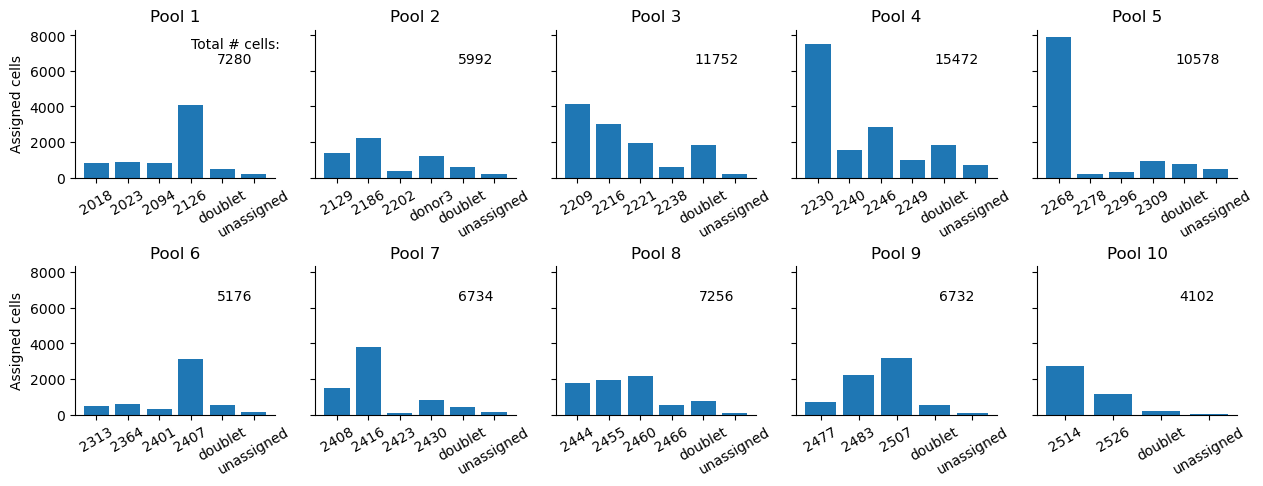

In [186]:
plot_assigned_cells_per_pool_hist("bulk", sample_id_mapping, False)

In [110]:
# Check which samples have less than 500 cells assigned to them
for i in range(1, n_pool + 1):
    tally = bulk_df.loc[bulk_df["pool"]==i, "donor_id"].value_counts()
    tally.drop(["doublet", "unassigned"], inplace=True)
    
    if not tally[tally < 500].empty:
        print(f"pool {i}")
        print(tally[tally < 500])

pool 2
230509/2202    388
Name: donor_id, dtype: int64
pool 5
230626/2296    300
230626/2278    200
Name: donor_id, dtype: int64
pool 6
230509/2313    452
230509/2401    331
Name: donor_id, dtype: int64
pool 7
230626/2423    91
Name: donor_id, dtype: int64


In [109]:
# Check which samples have less than 500 cells assigned to them
for i in range(1, n_pool + 1):
    tally = diss_df.loc[diss_df["pool"]==i, "donor_id"].value_counts()
    tally.drop(["doublet", "unassigned"], inplace=True)
    
    if not tally[tally < 500].empty:
        print(f"pool {i}")
        print(tally[tally < 500])

pool 2
230414/2202    407
Name: donor_id, dtype: int64
pool 6
230414/2407    330
Name: donor_id, dtype: int64
pool 7
230418/2309    32
Name: donor_id, dtype: int64


# Compare bulk and diss bulk refs

In [16]:
bulk_sub_df = bulk_df[["cell", "donor_id", "pool"]]
diss_bulk_sub_df = diss_df[["cell", "donor_id", "pool"]]

In [17]:
df = pd.merge(
    bulk_sub_df, 
    diss_bulk_sub_df, 
    how="outer", 
    on=["cell", "pool"], 
    suffixes=["_bulk", "_diss"]
)

In [22]:
df = df.replace(r"\d{6}/", "", regex=True)

In [39]:
# Mapping the dissociated bulk sample ids to what they ought to be
mapping_dict = sample_id_mapping[["Bulk sample id", "Diss bulk sample id"]].set_index("Diss bulk sample id").to_dict()["Bulk sample id"]
mapping_dict = {str(k): str(v) for k, v in mapping_dict.items()}

In [42]:
df["donor_id_diss"] = df["donor_id_diss"].replace(mapping_dict)

In [46]:
counts_df = pd.DataFrame(
    {"Bulk counts": df["donor_id_bulk"].value_counts(),
     "Diss bulk counts": df["donor_id_diss"].value_counts(),
    }
)

In [53]:
counts_df = counts_df.drop(index=["donor1", "donor2", "donor3", "doublet", "unassigned"])

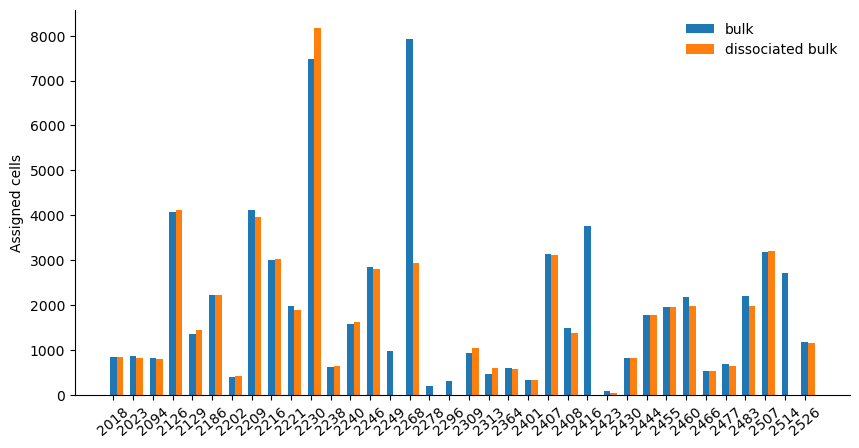

In [90]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(range(0, len(counts_df)*3, 3), counts_df["Bulk counts"], 1, label="bulk")
ax.bar(range(1, len(counts_df)*3, 3), counts_df["Diss bulk counts"], 1, label="dissociated bulk")
ax.set_xticks(range(0, len(counts_df)*3, 3))
ax.set_xticklabels(counts_df.index, rotation=40)
ax.set_ylabel("Assigned cells")
ax.spines[['right', 'top']].set_visible(False)
ax.legend(frameon=False, loc="upper right")

fig.show()

In [91]:
figname = f"plots/gex_dmx_barchart_assigned_cells"
fig.savefig(figname + ".pdf", bbox_inches="tight")
fig.savefig(figname + ".png", bbox_inches="tight", dpi=150)

(0.0, 8579.55)

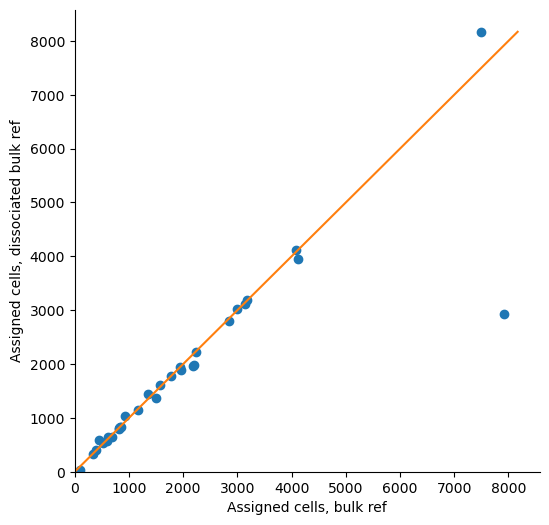

In [105]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(range(0, int(counts_df.max().max())), range(0, int(counts_df.max().max())), "C1")
ax.scatter(counts_df["Bulk counts"], counts_df["Diss bulk counts"])
ax.spines[['right', 'top']].set_visible(False)
ax.set_xlabel("Assigned cells, bulk ref")
ax.set_ylabel("Assigned cells, dissociated bulk ref")
ax.set_xlim(0, None)
ax.set_ylim(0, None)

In [106]:
figname = f"plots/gex_dmx_scatter_plot_assigned_cells"
fig.savefig(figname + ".pdf", bbox_inches="tight")
fig.savefig(figname + ".png", bbox_inches="tight", dpi=150)

# Compare dmx results

In [12]:
def load_gex_data_multi_condition(ref: Literal["bulk", "diss_bulk"]):
    
    df = pd.DataFrame()
    
    folders = [f"/vireo_{ref}", f"/vireo_{ref}_filter_qual", f"/vireo_{ref}_filter_qual_rd"]
    
    for folder in folders:
        for pool in range(1, n_pool + 1):

            gex_file = cwd + f"{folder}/pool{pool}/donor_ids.tsv"
            gex_df = pd.read_csv(gex_file, delimiter="\t")
            gex_df["pool"] = pool
            gex_df["folder"] = folder

            df = pd.concat([df, gex_df])
        
    df.reset_index(drop=True, inplace=True)
    
    return df

In [66]:
all_bulk_df = load_gex_data_multi_condition("bulk")
all_diss_df = load_gex_data_multi_condition("diss_bulk")

In [67]:
all_diss_df.head()

,cell,donor_id,prob_max,prob_doublet,n_vars,best_singlet,best_doublet,doublet_logLikRatio,pool,folder
0,AAACCCAAGAACCCGA-1,230418/2094,1.0,2.860000e-91,1621,230418/2094,"230414/2018,230418/2094",-205.534,1,/vireo_diss_bulk
1,AAACCCAAGCCTATCA-1,230414/2126,1.0,2.400000e-07,867,230414/2126,"230414/2023,230418/2094",-12.293,1,/vireo_diss_bulk
2,AAACCCAAGCTGAGCA-1,230414/2126,1.0,6.680000e-222,1528,230414/2126,"230414/2023,230418/2094",-506.325,1,/vireo_diss_bulk
3,AAACCCACAAGAGTTA-1,230414/2018,1.0,1.410000e-19,1062,230414/2018,"230414/2018,230418/2094",-40.457,1,/vireo_diss_bulk
4,AAACCCAGTCATCGGC-1,230414/2126,1.0,8.460000e-107,1445,230414/2126,"230414/2023,230418/2094",-241.292,1,/vireo_diss_bulk


In [68]:
len(all_bulk_df)

243222

In [190]:
def plot_assigned_cells_per_pool_hist_multi(ref: Literal["bulk", "diss_bulk"], sample_id_mapping: pd.DataFrame, save: bool = False):
    
    if ref == "bulk":
        df = all_bulk_df.copy()
    elif ref == "diss_bulk":
        df = all_diss_df.copy()
        sample_id_map = sample_id_mapping[["Bulk sample id", "Diss bulk sample id"]].set_index("Diss bulk sample id").to_dict()["Bulk sample id"]
        sample_id_map = {str(k): str(v) for k, v in sample_id_map.items()}
        
    df = df.replace({r"\d{6}/": ""}, regex=True)
    if ref == "diss_bulk":
        df["donor_id"] = df["donor_id"].replace(sample_id_map)
        
    labels = ["original", "qual filter", "qual & rd filter"]

    fig, ax = plt.subplots(2, 5, figsize=(15, 5), sharey=True)

    for i in range(1, n_pool + 1):
        index_y = (i-1)%5
        index_x = (i-1)//5
        
        for j, folder in enumerate([f"/vireo_{ref}", f"/vireo_{ref}_filter_qual", f"/vireo_{ref}_filter_qual_rd"]):
            sub_df = df[df["folder"]==folder]
            hist_data = sub_df.loc[sub_df["pool"]==i, "donor_id"].value_counts()
            hist_order = sorted(hist_data.index)
            hist_data = hist_data[hist_order]
            ax[index_x, index_y].bar(range(j, 4*len(hist_data)+j, 4), hist_data, 1, label=labels[j])
        ax[index_x, index_y].set_title(f"Pool {i}")
        ax[index_x, index_y].spines[['right', 'top']].set_visible(False)
        ax[index_x, index_y].set_xticks(range(0, len(hist_data)*4, 4))
        ax[index_x, index_y].set_xticklabels(hist_data.index, rotation=30, ha="center")
        ax[index_x, index_y].text(0.8, 0.8, f"{hist_data.sum()}", ha="center", va="center", transform=ax[index_x, index_y].transAxes)
        
    ax[0, 0].set_ylabel("Assigned cells")
    ax[1, 0].set_ylabel("Assigned cells")
    ax[0, 0].text(0.8, 0.9, "Total # cells:", ha="center", va="center", transform=ax[0, 0].transAxes)
    ax[0, 4].legend(frameon=False, loc=(1, 0.5))

    fig.subplots_adjust(hspace=0.6)
    plt.show()
    
    if save:
        figname = f"plots/gex_dmx_{ref}_assigned_cells_multi"
        fig.savefig(figname + ".pdf", bbox_inches="tight")
        fig.savefig(figname + ".png", bbox_inches="tight", dpi=150)

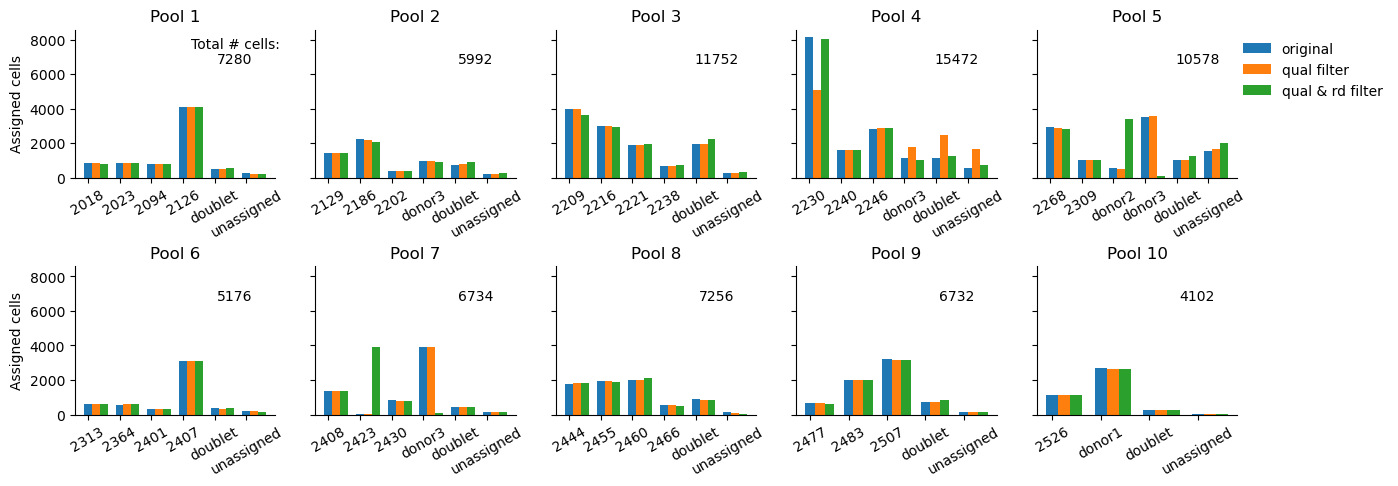

In [194]:
plot_assigned_cells_per_pool_hist_multi("diss_bulk", sample_id_mapping, True)